# 1. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from itertools import product
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

import warnings

warnings.filterwarnings("ignore")

Read train and test data

In [ ]:
df = pd.read_csv("train (1).csv")
df_test = pd.read_csv("test (1).csv")

# 2. EDA (Exploratory Data Analysis)
Analysis of available data to check if there is null or empty data, and types of columns. The correlation between variables is also explored to take ignore it

## 2.1 EDA General Data

Amount of nulls per column

In [4]:
print(f"|{'# of Null in Train':>20}|")
print(f"{df.isnull().sum()}|")

|  # of Null in Train|
ID                    0
Edad                  0
Tipo_Trabajo          0
Estado_Civil          0
Educacion             0
Incumplimiento        0
Vivienda              0
Consumo               0
Contacto              0
Mes                   0
Dias                  0
Campana               0
Dias_Ultima_Camp      0
No_Contactos          0
Resultado_Anterior    0
emp_var_rate          0
cons_price_idx        0
cons_conf_idx         0
euribor3m             0
nr_employed           0
y                     0
dtype: int64|


Amount of unique categories per column

In [5]:
df.apply(lambda col: col.nunique())

ID                    26373
Edad                     75
Tipo_Trabajo             12
Estado_Civil              4
Educacion                 8
Incumplimiento            3
Vivienda                  3
Consumo                   3
Contacto                  2
Mes                      10
Dias                      5
Campana                  40
Dias_Ultima_Camp         26
No_Contactos              7
Resultado_Anterior        3
emp_var_rate             10
cons_price_idx           26
cons_conf_idx            26
euribor3m               306
nr_employed              11
y                         2
dtype: int64

In [ ]:
df.describe(include="all")

,ID,Edad,Tipo_Trabajo,Estado_Civil,Educacion,Incumplimiento,Vivienda,Consumo,Contacto,Mes,...,Campana,Dias_Ultima_Camp,No_Contactos,Resultado_Anterior,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
count,26373.000000,26373.000000,26373,26373,26373,26373,26373,26373,26373,26373,...,26373.000000,26373.000000,26373.000000,26373,26373.000000,26373.000000,26373.000000,26373.000000,26373.000000,26373.000000
unique,NaN,NaN,12,4,8,3,3,3,2,10,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,admin.,married,university.degree,no,yes,no,cellular,may,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,6657,15957,7623,20896,13921,21727,16659,8833,...,NaN,NaN,NaN,22845,NaN,NaN,NaN,NaN,NaN,NaN
mean,16423.772040,40.039245,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.587078,962.857051,0.169643,NaN,0.096003,85606.636477,-40.504031,3192.809493,5167.531362,0.112919
std,9506.996292,10.413698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.818767,185.963406,0.491433,NaN,1.565612,26179.858733,4.608465,2086.437238,72.052888,0.316499
min,1.000000,17.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,93.200000,-50.800000,0.634000,4963.600000,0.000000
25%,8191.000000,32.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,92893.000000,-42.700000,1281.000000,5099.100000,0.000000
50%,16383.000000,38.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93798.000000,-41.800000,4856.000000,5191.000000,0.000000
75%,24632.000000,47.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93994.000000,-36.400000,4961.000000,5228.100000,0.000000


## 2.2 EDA Graphs per column
Besides the graphs, some rows were removed based on the EDA process

### 2.2.1 Boxplots

Boxplot for the 2 variables with the most unique categories

<Axes: title={'center': 'Euribor 3 Month Rate'}>

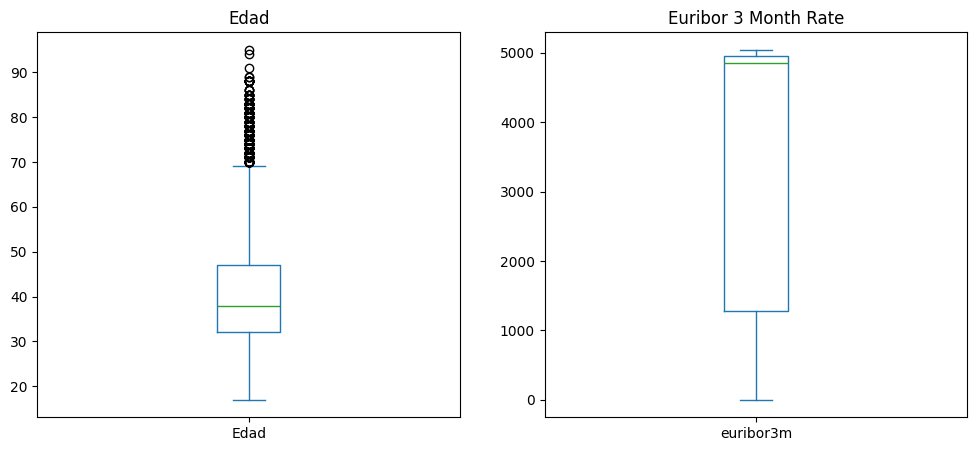

In [ ]:
plt.subplot(121)
df["Edad"].plot(kind="box", figsize=(12, 5), title="Edad")
plt.subplot(122)
df["euribor3m"].plot(kind="box", title="Euribor 3 Month Rate")

Remove outliers based on empiric knowledge and the previous boxplot
Validate also that the distribution of Y-label doesn't change

In [ ]:
df_new = df[df["Edad"] <= 80]
print(f"There were removed {len(df) - len(df_new)} rows with Edad > 80")
print(
    f"Variable Y[%] in df_new \n{df_new['y'].value_counts(normalize=True)} \ny variable Y[%] in df \n{df['y'].value_counts(normalize=True)} "
)

There were removed 75 rows with Edad > 80
Variable Y[%] in df_new 
y
0    0.88809
1    0.11191
Name: proportion, dtype: float64 
y variable Y[%] in df 
y
0    0.887081
1    0.112919
Name: proportion, dtype: float64 


### 2.2.2 Histograms

Histograms for the rest of numeric variables

<Axes: title={'center': '# of Employees'}, xlabel='nr_employed'>

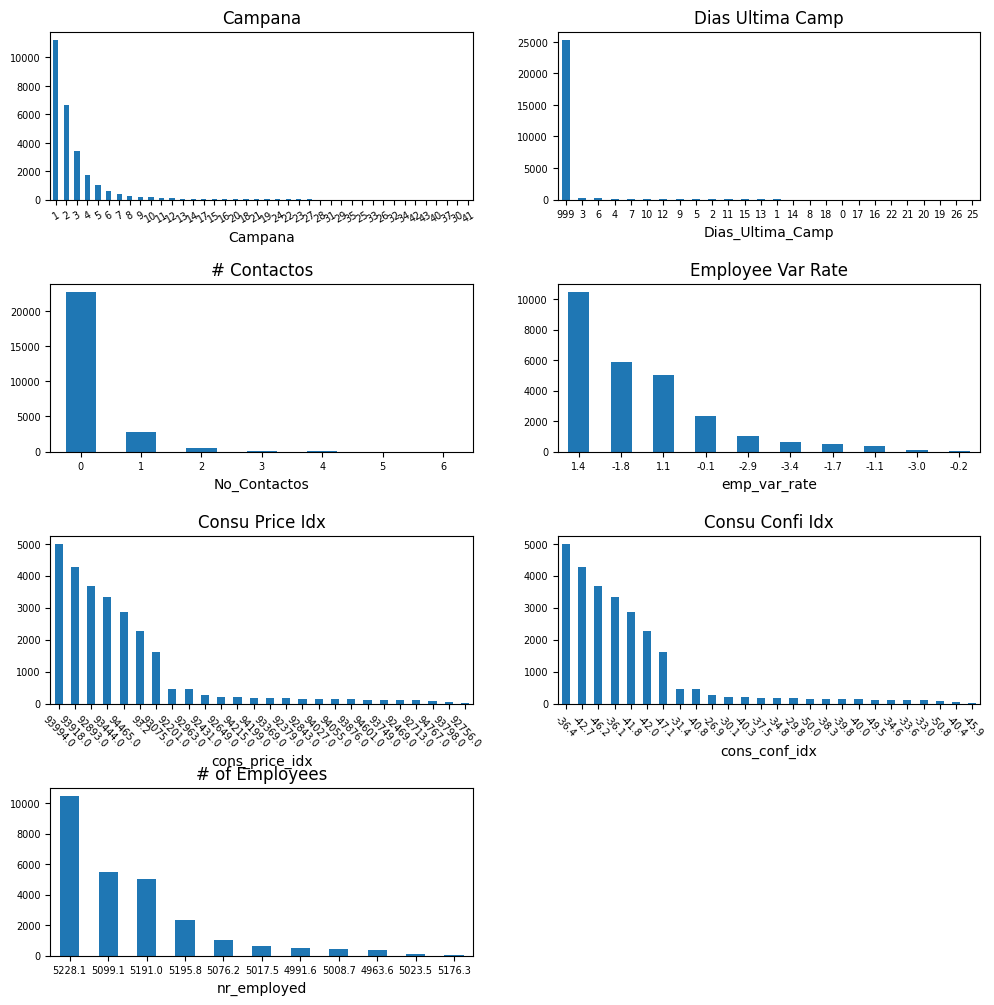

In [ ]:
plt.subplots_adjust(hspace=0.5)
plt.subplot(421)
df_new["Campana"].value_counts().plot(
    kind="bar", rot=30, fontsize=7, title="Campana", figsize=(12, 12)
)

plt.subplot(422)
df_new["Dias_Ultima_Camp"].value_counts().plot(
    kind="bar", fontsize=7, title="Dias Ultima Camp", rot=0
)
plt.subplot(423)
df_new["No_Contactos"].value_counts().plot(
    kind="bar", fontsize=7, title="# Contactos", rot=0
)
plt.subplot(424)
df_new["emp_var_rate"].value_counts().plot(
    kind="bar", fontsize=7, title="Employee Var Rate", rot=0
)
plt.subplot(425)
df_new["cons_price_idx"].value_counts().plot(
    kind="bar", fontsize=7, title="Consu Price Idx", rot=-45
)
plt.subplot(426)
df_new["cons_conf_idx"].value_counts().plot(
    kind="bar", fontsize=7, title="Consu Confi Idx", rot=-45
)
plt.subplot(427)
df_new["nr_employed"].value_counts().plot(
    kind="bar", fontsize=7, title="# of Employees", rot=0
)


# Dias_Ultima_Camp	No_Contactos	emp_var_rate	cons_price_idx	cons_conf_idx	euribor3m	nr_employed

Remove the rows with the lowest amount of clients per category in each variable

In [ ]:
df_new2 = df_new[
    (df_new["No_Contactos"] < 3)
    & (df_new["Campana"] <= 13)
    & (
        (df_new["Dias_Ultima_Camp"] == 999)
        | (df_new["Dias_Ultima_Camp"] == 3)
        | (df_new["Dias_Ultima_Camp"] == 6)
    )
    & (df_new["nr_employed"] != 5176.3)
    & (df_new["emp_var_rate"] != -0.2)
    & (df_new["cons_price_idx"] != 92756)
    & (df_new["cons_conf_idx"] != -45.9)
]

print(f"{len(df_new) - len(df_new2)} removed rows")
print(
    f"Variable Y[%] in df_new2 \n{df_new2['y'].value_counts(normalize=True)} \ny variable Y[%] in df_new \n{df_new['y'].value_counts(normalize=True)} "
)

866 removed rows
Variable Y[%] in df_new2 
y
0    0.897216
1    0.102784
Name: proportion, dtype: float64 
y variable Y[%] in df_new 
y
0    0.88809
1    0.11191
Name: proportion, dtype: float64 


Histograms for the categorical variables

<Axes: title={'center': 'Resultado_Anterior'}, xlabel='Resultado_Anterior'>

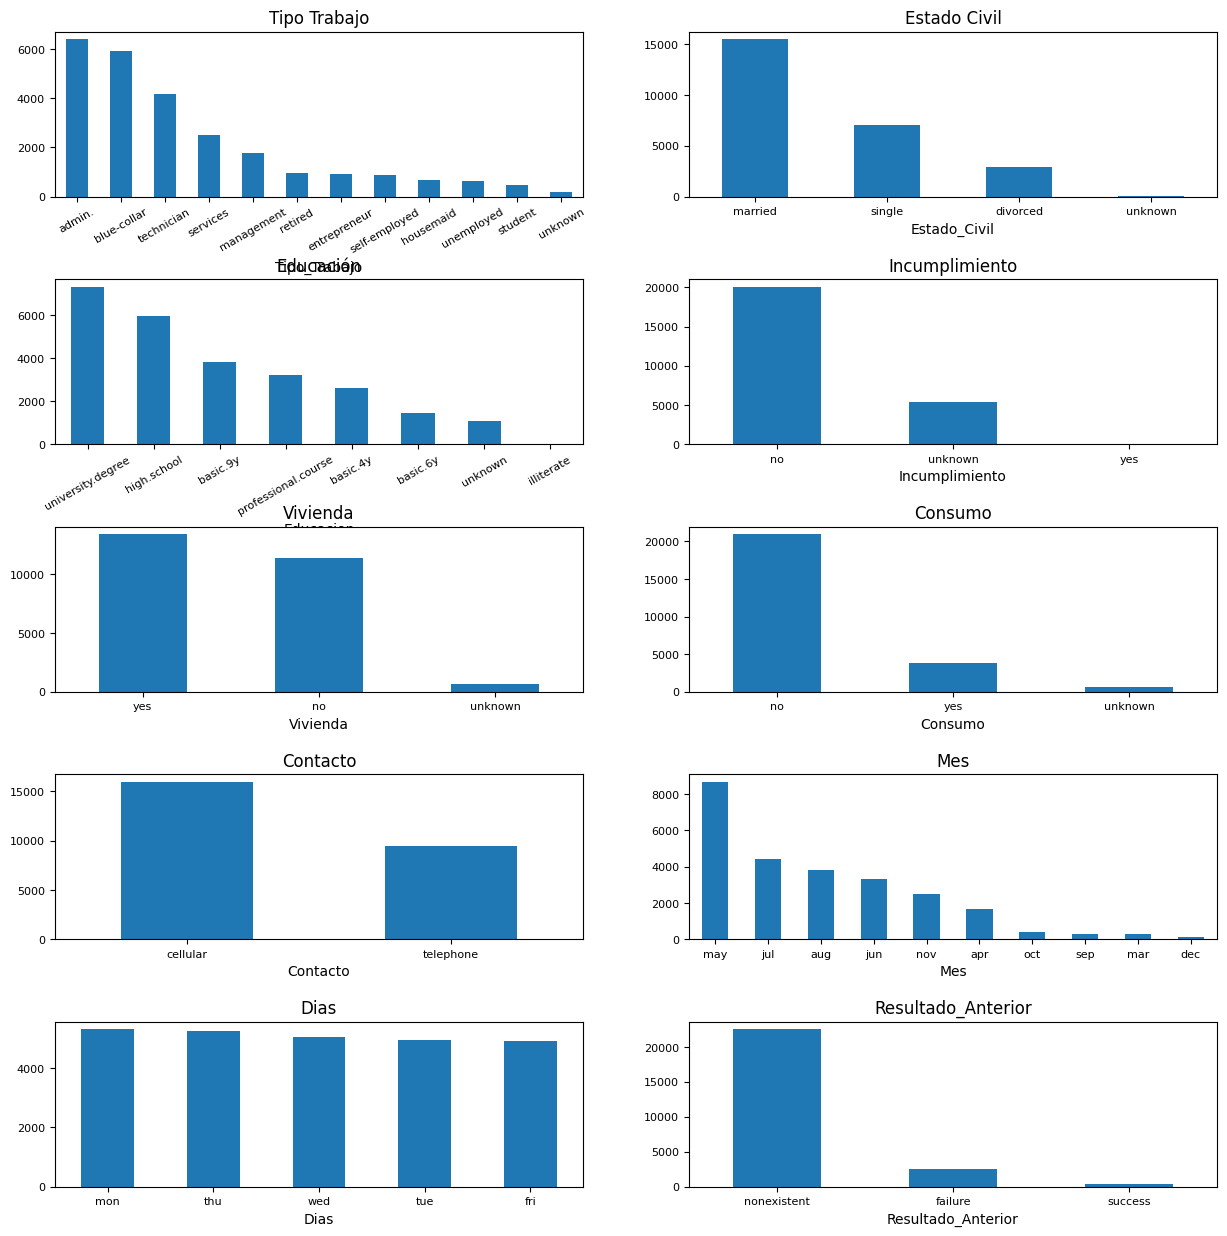

In [ ]:
plt.subplots_adjust(hspace=0.5)
plt.subplot(521)
df_new2["Tipo_Trabajo"].value_counts().plot(
    kind="bar", title="Tipo Trabajo", rot=30, fontsize=8, figsize=(15, 15)
)
plt.subplot(522)
df_new2["Estado_Civil"].value_counts().plot(
    kind="bar", title="Estado Civil", rot=0, fontsize=8
)
plt.subplot(523)
df_new2["Educacion"].value_counts().plot(
    kind="bar", title="Educación", rot=30, fontsize=8
)
plt.subplot(524)
df_new2["Incumplimiento"].value_counts().plot(
    kind="bar", title="Incumplimiento", rot=0, fontsize=8
)
plt.subplot(525)
df_new2["Vivienda"].value_counts().plot(kind="bar", title="Vivienda", rot=0, fontsize=8)
plt.subplot(526)
df_new2["Consumo"].value_counts().plot(kind="bar", title="Consumo", rot=0, fontsize=8)
plt.subplot(527)
df_new2["Contacto"].value_counts().plot(kind="bar", title="Contacto", rot=0, fontsize=8)
plt.subplot(528)
df_new2["Mes"].value_counts().plot(kind="bar", title="Mes", rot=0, fontsize=8)
plt.subplot(529)
df_new2["Dias"].value_counts().plot(kind="bar", title="Dias", rot=0, fontsize=8)
plt.subplot(5, 2, 10)
df_new2["Resultado_Anterior"].value_counts().plot(
    kind="bar", title="Resultado_Anterior", rot=0, fontsize=8
)
# Educacion	Incumplimiento	Vivienda	Consumo	Contacto	Mes	Dias	Resultado_Anterior

Remove the rows with the lowest amount of clients per category in each variable

In [ ]:
df_new3 = df_new2[
    (df_new2["Estado_Civil"] != "unknown") & (df_new2["Incumplimiento"] != "yes")
]
print(f"Se removieron {len(df_new2) - len(df_new3)} datos")
print(
    f"Variable Y[%] en df_new3 \n{df_new3['y'].value_counts(normalize=True)} \ny variable Y[%] en df_new2 \n{df_new2['y'].value_counts(normalize=True)} "
)

Se removieron 47 datos
Variable Y[%] en df_new3 
y
0    0.897341
1    0.102659
Name: proportion, dtype: float64 
y variable Y[%] en df_new2 
y
0    0.897216
1    0.102784
Name: proportion, dtype: float64 


## 2.3 Correlation and Chi Square

Divide data in numeric and categorical variables

In [ ]:
df_cat = df_new3.select_dtypes(include=["object"])
df_num = df_new3.select_dtypes(exclude=["object"])
df_cat["y"] = df_new3["y"].apply(lambda x: "yes" if x == 1 else "no")

### 2.3.1 Linear correlation in numerical variables

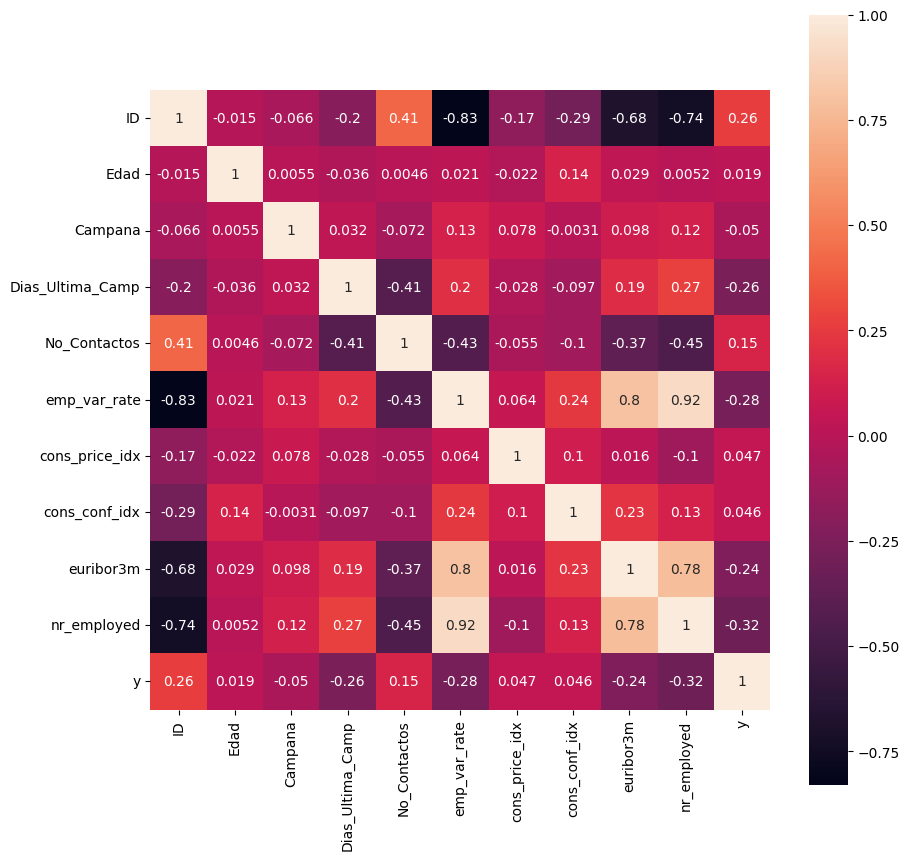

In [ ]:
corr = df_num.corr(method="pearson")
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(corr, annot=True, square=True, ax=ax)
plt.yticks(rotation=0)
plt.show()

Based on the result the age was removed due to its low correlation, which will not affect the predictions in the model.

### 2.3.2 Chi Square correlation for categorical values

In [ ]:
cat_var1 = tuple(df_cat.columns)
cat_var2 = tuple(df_cat.columns)
cat_var_prod = list(product(cat_var1, cat_var2, repeat=1))
result = []
for i in cat_var_prod:
    if i[0] != i[1]:
        result.append(
            (
                i[0],
                i[1],
                list(chi2_contingency(pd.crosstab(df_cat[i[0]], df_cat[i[1]])))[1],
            )
        )

In [ ]:
chi_test_output = pd.DataFrame(result, columns=["var1", "var2", "coeff"])
chi_test_output_piv = chi_test_output.pivot(
    index="var1", columns="var2", values="coeff"
)
chi_test_output_piv

var2,Consumo,Contacto,Dias,Educacion,Estado_Civil,Incumplimiento,Mes,Resultado_Anterior,Tipo_Trabajo,Vivienda,y
var1,,,,,,,,,,,
Consumo,NaN,1.443490e-03,1.238489e-01,2.028171e-01,5.095427e-01,2.253074e-01,2.616612e-02,7.975720e-01,3.321528e-01,0.000000e+00,3.521234e-01
Contacto,0.001443,NaN,2.878426e-17,3.557451e-82,5.529357e-29,1.002884e-99,0.000000e+00,1.057700e-272,1.465147e-76,2.484792e-39,2.197215e-97
Dias,0.123849,2.878426e-17,NaN,2.290905e-05,2.045478e-02,6.585876e-01,9.083021e-81,2.155455e-01,7.830929e-04,1.171156e-02,3.165016e-03
Educacion,0.202817,3.557451e-82,2.290905e-05,NaN,1.012765e-212,0.000000e+00,1.657887e-305,3.965420e-13,0.000000e+00,2.073955e-02,2.783658e-21
Estado_Civil,0.509543,5.529357e-29,2.045478e-02,1.012765e-212,NaN,1.478674e-97,4.185535e-38,6.377179e-10,0.000000e+00,2.759871e-01,8.478958e-16
Incumplimiento,0.225307,1.002884e-99,6.585876e-01,0.000000e+00,1.478674e-97,NaN,1.077036e-124,1.029984e-52,8.090550e-231,3.214728e-02,6.669249e-51
Mes,0.026166,0.000000e+00,9.083021e-81,1.657887e-305,4.185535e-38,1.077036e-124,NaN,0.000000e+00,0.000000e+00,7.100027e-27,0.000000e+00
Resultado_Anterior,0.797572,1.057700e-272,2.155455e-01,3.965420e-13,6.377179e-10,1.029984e-52,0.000000e+00,NaN,1.344420e-62,7.129859e-02,0.000000e+00
Tipo_Trabajo,0.332153,1.465147e-76,7.830929e-04,0.000000e+00,0.000000e+00,8.090550e-231,0.000000e+00,1.344420e-62,NaN,2.035587e-01,3.540746e-96


P-Value between variables

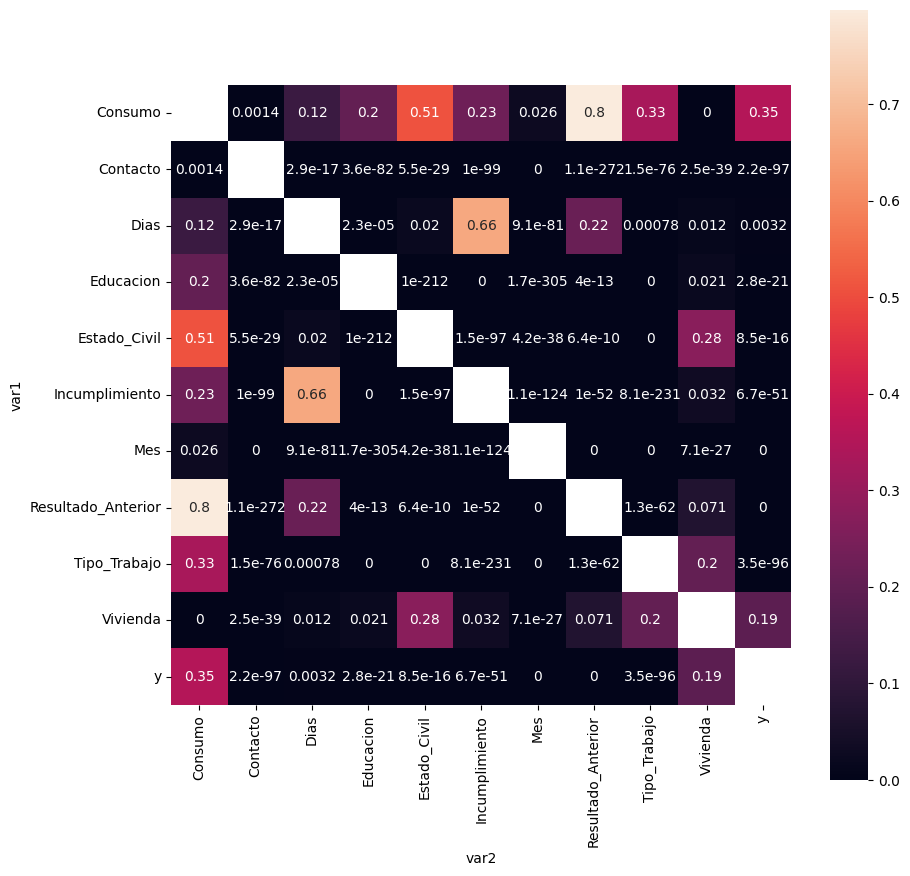

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(chi_test_output_piv, annot=True, square=True, ax=ax)
plt.yticks(rotation=0)
plt.show()

Cálculo de chi cuadrado y el p-value para evaluar correlación entre todas las variables

In [ ]:
var1 = tuple(df_new3.drop(["ID"], axis=1).columns)
var2 = tuple(df_new3.drop(["ID"], axis=1).columns)
var_prod = list(product(var1, var2, repeat=1))
result2 = []
for i in var_prod:
    if i[0] != i[1]:
        result2.append(
            (
                i[0],
                i[1],
                list(chi2_contingency(pd.crosstab(df_new3[i[0]], df_new3[i[1]])))[1],
            )
        )

In [ ]:
chi_test_output2 = pd.DataFrame(result2, columns=["var1", "var2", "coeff"])
chi_test_output_piv2 = chi_test_output2.pivot(
    index="var1", columns="var2", values="coeff"
)
chi_test_output_piv2

var2,Campana,Consumo,Contacto,Dias,Dias_Ultima_Camp,Edad,Educacion,Estado_Civil,Incumplimiento,Mes,No_Contactos,Resultado_Anterior,Tipo_Trabajo,Vivienda,cons_conf_idx,cons_price_idx,emp_var_rate,euribor3m,nr_employed,y
var1,,,,,,,,,,,,,,,,,,,,
Campana,NaN,0.355733,5.374061e-13,7.083897e-33,1.200328e-01,3.215562e-01,6.612356e-01,7.132633e-01,9.562040e-05,2.291325e-88,1.307260e-21,1.054163e-20,8.698554e-03,1.622325e-01,7.680980e-103,7.680980e-103,1.515911e-124,1.669261e-16,1.950464e-120,1.898515e-10
Consumo,3.557330e-01,NaN,1.443490e-03,1.238489e-01,2.355049e-01,1.328947e-01,2.028171e-01,5.095427e-01,2.253074e-01,2.616612e-02,9.729075e-01,7.975720e-01,3.321528e-01,0.000000e+00,3.480137e-03,3.480137e-03,1.338120e-01,2.218186e-04,9.562824e-02,3.521234e-01
Contacto,5.374061e-13,0.001443,NaN,2.878426e-17,1.724087e-35,8.647931e-44,3.557451e-82,5.529357e-29,1.002884e-99,0.000000e+00,8.940726e-273,1.057700e-272,1.465147e-76,2.484792e-39,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.197215e-97
Dias,7.083897e-33,0.123849,2.878426e-17,NaN,4.202060e-01,3.187985e-09,2.290905e-05,2.045478e-02,6.585876e-01,9.083021e-81,3.860730e-01,2.155455e-01,7.830929e-04,1.171156e-02,1.304531e-100,1.304531e-100,4.197498e-43,0.000000e+00,6.673183e-43,3.165016e-03
Dias_Ultima_Camp,1.200328e-01,0.235505,1.724087e-35,4.202060e-01,NaN,2.092592e-120,5.002442e-10,5.519046e-05,5.691908e-22,0.000000e+00,0.000000e+00,0.000000e+00,9.650450e-55,2.255818e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Edad,3.215562e-01,0.132895,8.647931e-44,3.187985e-09,2.092592e-120,NaN,0.000000e+00,0.000000e+00,1.235680e-237,0.000000e+00,1.716233e-97,1.621956e-121,0.000000e+00,9.062871e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.845791e-136
Educacion,6.612356e-01,0.202817,3.557451e-82,2.290905e-05,5.002442e-10,0.000000e+00,NaN,1.012765e-212,0.000000e+00,1.657887e-305,4.300641e-07,3.965420e-13,0.000000e+00,2.073955e-02,0.000000e+00,0.000000e+00,2.322179e-149,1.300925e-199,1.332753e-167,2.783658e-21
Estado_Civil,7.132633e-01,0.509543,5.529357e-29,2.045478e-02,5.519046e-05,0.000000e+00,1.012765e-212,NaN,1.478674e-97,4.185535e-38,6.160862e-09,6.377179e-10,0.000000e+00,2.759871e-01,6.504576e-108,6.504576e-108,6.702199e-75,4.727982e-87,3.441811e-75,8.478958e-16
Incumplimiento,9.562040e-05,0.225307,1.002884e-99,6.585876e-01,5.691908e-22,1.235680e-237,0.000000e+00,1.478674e-97,NaN,1.077036e-124,3.186211e-48,1.029984e-52,8.090550e-231,3.214728e-02,1.711433e-285,1.711433e-285,3.316599e-280,1.674324e-170,3.355586e-287,6.669249e-51


Gráfico de p-value entre todas las variables

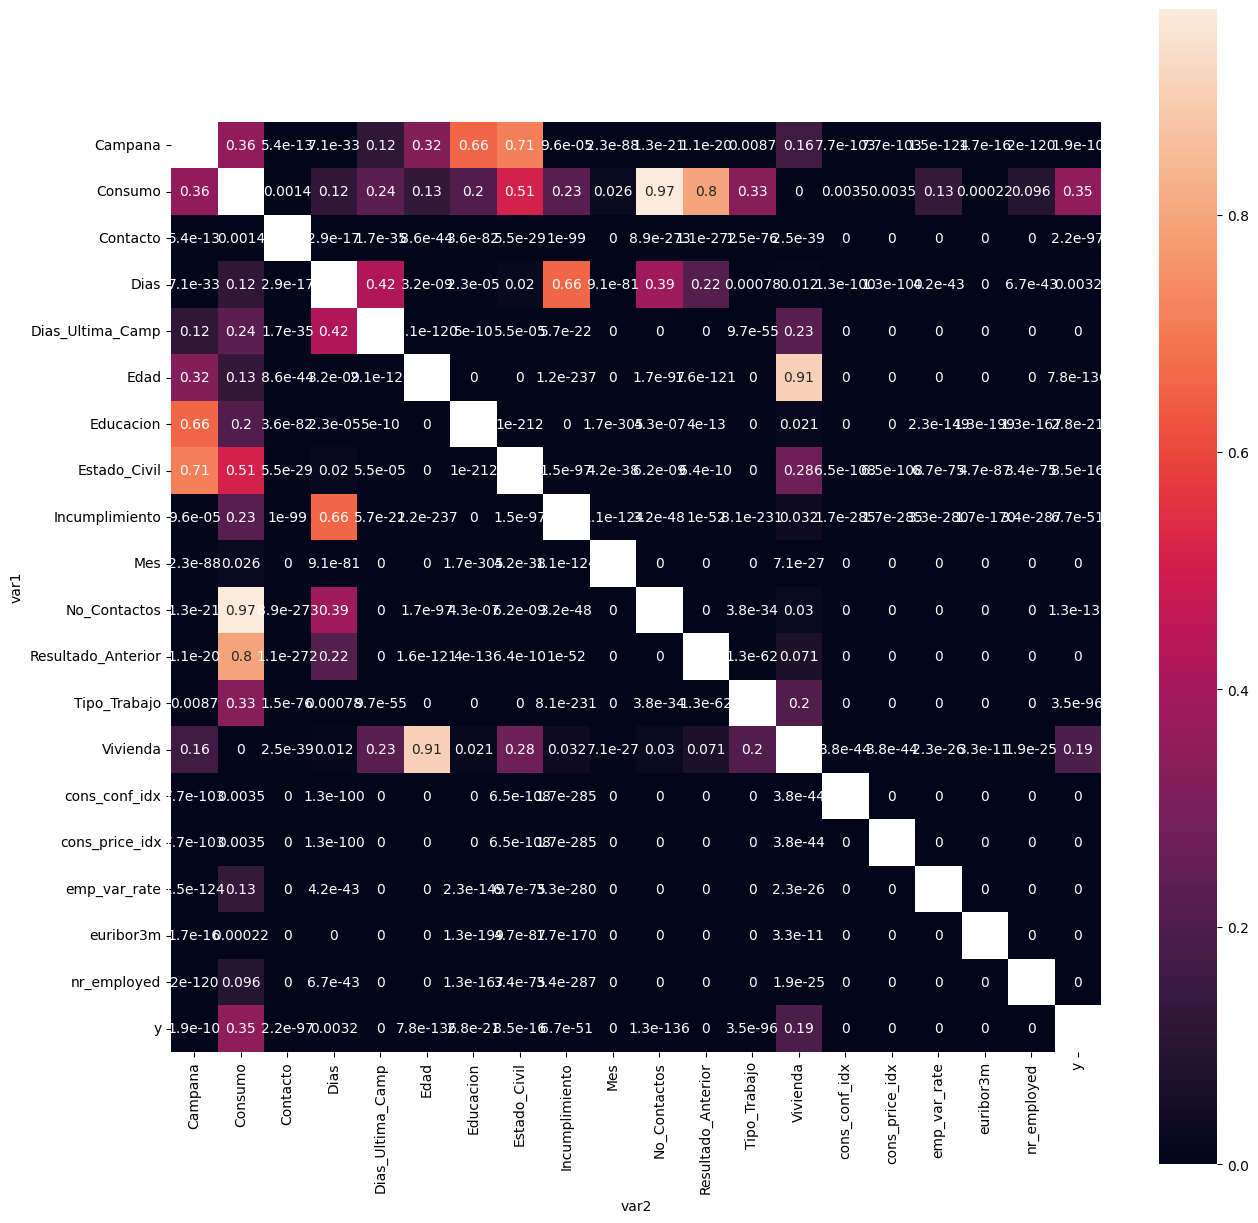

In [ ]:
fig, ax = plt.subplots(figsize=(15, 15))
sns.heatmap(chi_test_output_piv2, annot=True, square=True, ax=ax)
plt.yticks(rotation=0)
plt.show()

Based on the results of the Chi Square, I decided to remove the "Consumo" and "Vivienda" variables

In [ ]:
cols_final = df_new3.drop(["Consumo", "Vivienda"], axis=1).columns

df_new4 = df_new3[cols_final]

df_test2 = df_test[cols_final[:-1]]

# 3. Preprocessing Data
A preprocessing for data was made. The categorical variables were passed through an Ordinal Encoder so they can be processed later in the models.
The numeric variables were normalized using a Standard Scaler to have them in the same scale

## 3.1 Categorical Variables

In [ ]:
def preprocess_data(df):
    ## Se utilizó OrdinalEncoder para transformar las variables categóricas a variables numéricas
    categorical_preprocessor = OrdinalEncoder()

    df["Contacto_int"] = categorical_preprocessor.fit_transform(
        df["Contacto"].values.reshape(len(df), 1)
    )
    df["Dias_int"] = categorical_preprocessor.fit_transform(
        df["Dias"].values.reshape(len(df), 1)
    )
    df["Mes_int"] = categorical_preprocessor.fit_transform(
        df["Mes"].values.reshape(len(df), 1)
    )
    df["Resultado_Anterior_int"] = categorical_preprocessor.fit_transform(
        df["Resultado_Anterior"].values.reshape(len(df), 1)
    )
    df["Tipo_Trabajo_int"] = categorical_preprocessor.fit_transform(
        df["Tipo_Trabajo"].values.reshape(len(df), 1)
    )
    df["Estado_Civil_int"] = categorical_preprocessor.fit_transform(
        df["Estado_Civil"].values.reshape(len(df), 1)
    )
    df["Educacion_int"] = categorical_preprocessor.fit_transform(
        df["Educacion"].values.reshape(len(df), 1)
    )
    df["Incumplimiento_int"] = categorical_preprocessor.fit_transform(
        df["Incumplimiento"].values.reshape(len(df), 1)
    )

    cols_train_test = [
        "ID",
        "Dias_Ultima_Camp",
        "No_Contactos",
        "emp_var_rate",
        "euribor3m",
        "cons_conf_idx",
        "cons_price_idx",
        "Campana",
        "nr_employed",
        "Contacto_int",
        "Dias_int",
        "Educacion_int",
        "Estado_Civil_int",
        "Incumplimiento_int",
        "Mes_int",
        "Resultado_Anterior_int",
        "Tipo_Trabajo_int",
    ]

    df_final = df[cols_train_test].set_index("ID")

    return df_final

In [23]:
df_train = preprocess_data(df_new4)
df_test3 = preprocess_data(df_test2)

## 3.2 Numerical Variables

In [ ]:
data = StandardScaler().fit_transform(df_train.values)
target = df_new4["y"].to_numpy()
df_test_train = StandardScaler().fit_transform(df_test3.values)
data_train, data_val, target_train, target_val = train_test_split(
    data, target, test_size=0.3, stratify=target, random_state=42
)

# 4. Training Model
A Logistic Regression was trained, which is the most basic classification model.
Due to the fact that the data is unbalanced, two approaches were done. The first approach was balancing data based on the hyperparameter available in the logistic regression mode abd the other approach using SMOTE.

## 4.1 Inner Balancing

In [ ]:
model = LogisticRegression(max_iter=500, class_weight="balanced")
_ = model.fit(data_train, target_train)

In [26]:
target_pred = model.predict(data_val)
test_pred = model.predict(df_test_train)

In [27]:
print(f"Mean accuracy is: {model.score(data_val, target_val)}")
print(f"ROC-AUC Score is: {roc_auc_score(target_val, target_pred)}")
print(f"Classification Report:\n  {classification_report(target_val, target_pred)}")
print(f"Confusion Matrix:\n {confusion_matrix(target_val, target_pred)}")

Mean accuracy is: 0.7689075630252101
ROC-AUC Score is: 0.7109910804036086
Classification Report:
                precision    recall  f1-score   support

           0       0.95      0.78      0.86      6834
           1       0.25      0.64      0.36       782

    accuracy                           0.77      7616
   macro avg       0.60      0.71      0.61      7616
weighted avg       0.88      0.77      0.81      7616

Confusion Matrix:
 [[5357 1477]
 [ 283  499]]


## 4.2 SMOTE Balancing

Balanceo de clases

In [ ]:
smote = SMOTE(random_state=42, sampling_strategy=0.8)
x_smote, y_smote = smote.fit_resample(data_train, target_train)

Modelo, predicción y resultados

In [29]:
model = LogisticRegression(max_iter=500)
_ = model.fit(x_smote, y_smote)
target_pred = model.predict(data_val)
test_pred = model.predict(df_test_train)
print(f"Mean accuracy is: {model.score(data_val, target_val)}")
print(f"ROC-AUC Score is: {roc_auc_score(target_val, target_pred)}")
print(f"Classification Report:\n  {classification_report(target_val, target_pred)}")
print(f"Confusion Matrix:\n {confusion_matrix(target_val, target_pred)}")

Mean accuracy is: 0.7984506302521008
ROC-AUC Score is: 0.7166946596938581
Classification Report:
                precision    recall  f1-score   support

           0       0.95      0.82      0.88      6834
           1       0.28      0.61      0.38       782

    accuracy                           0.80      7616
   macro avg       0.61      0.72      0.63      7616
weighted avg       0.88      0.80      0.83      7616

Confusion Matrix:
 [[5601 1233]
 [ 302  480]]


## 4.3 Final File

In [30]:
submission = pd.DataFrame({"ID": df_test3.index, "y": test_pred})
submission.to_csv("submission.csv", index=False)

# 5. Model Evaluation
A model evaluation was made making kind of a Grid Search but with actual FOR loops varying multiple hyperparameters from the following models: Logistic Regression, Random Forest Classifier, Gradient Boosting Classifier and XGBoost Classifier.
The model with the best ROC-AUC Score was chosen. 

## 5.1 Logistic Regression

In [ ]:
penalty = ["l1", "l2", "elasticnet"]
c_val = [0.01, 0.1, 1]
score_lr = 0
for pen in penalty:
    for c in c_val:
        if pen == "elasticnet":
            model = LogisticRegression(
                penalty=pen, C=c, max_iter=500, l1_ratio=0.5, solver="saga"
            )
        else:
            model = LogisticRegression(penalty=pen, C=c, max_iter=500, solver="saga")

        _ = model.fit(x_smote, y_smote)
        target_pred = model.predict(data_val)
        score = roc_auc_score(target_val, target_pred)
        if score > score_lr:
            score_lr = score
            params = {"penalty": pen, "C": c, "score": score_lr}

print(f"El mejor modelo es: {params}")

El mejor modelo es: {'penalty': 'l2', 'C': 0.01, 'score': 0.7173690371671055}


## 5.2 Random Forest Classifier

In [ ]:
estimators = [25, 50, 100, 200, 500]
depth = [2, 5, 10, 20, None]
features = ["sqrt", "log2", None]
trainx_data_list = [x_smote, data_train]
trainy_data_list = [y_smote, target_train]
class_weight = ["balanced", None, "balanced_subsample"]
score_rf = 0
for xy in range(len(trainx_data_list)):
    for estimator in estimators:
        for max_depth in depth:
            for feature in features:
                for cl in class_weight:
                    model_rf = RandomForestClassifier(
                        n_estimators=estimator,
                        max_depth=max_depth,
                        max_features=feature,
                        class_weight=cl,
                        random_state=42,
                    )
                    _ = model_rf.fit(trainx_data_list[xy], trainy_data_list[xy])
                    target_pred_rf = model_rf.predict(data_val)
                    score = roc_auc_score(target_val, target_pred_rf)
                    print(f"{estimator}, {max_depth}, {feature}, {cl}, {score}")
                    if score > score_rf:
                        score_rf = score
                        params = {
                            "estimator": estimator,
                            "max_depth": max_depth,
                            "max_features": feature,
                            "class_weight": cl,
                            "data": xy,
                            "score": score_rf,
                        }

print(f"El mejor modelo es: {params}")

25, 2, sqrt, balanced, 0.705828275502284
25, 2, sqrt, None, 0.7158994032395568
25, 2, sqrt, balanced_subsample, 0.705828275502284
25, 2, log2, balanced, 0.705828275502284
25, 2, log2, None, 0.7158994032395568
25, 2, log2, balanced_subsample, 0.705828275502284
25, 2, None, balanced, 0.7131287297527706
25, 2, None, None, 0.7131287297527706
25, 2, None, balanced_subsample, 0.7131287297527706
25, 5, sqrt, balanced, 0.7190517998244074
25, 5, sqrt, None, 0.7160393683755137
25, 5, sqrt, balanced_subsample, 0.7172068048504282
25, 5, log2, balanced, 0.7190517998244074
25, 5, log2, None, 0.7160393683755137
25, 5, log2, balanced_subsample, 0.7172068048504282
25, 5, None, balanced, 0.7135804354188139
25, 5, None, None, 0.7168123576490948
25, 5, None, balanced_subsample, 0.7135804354188139
25, 10, sqrt, balanced, 0.7052620529068214
25, 10, sqrt, None, 0.7039005738570574
25, 10, sqrt, balanced_subsample, 0.7047880800600578
25, 10, log2, balanced, 0.7052620529068214
25, 10, log2, None, 0.703900573857

## 5.3 Gradient Boosting Classifier

In [ ]:
learning_rate = [0.001, 0.01, 0.1, 0.05]
estimators = [25, 50, 100, 200, 500]
depth = [3, 10, 15, 20]
features = ["sqrt", "log2", None]
score_gbc = 0
for lr in learning_rate:
    for estimator in estimators:
        for max_depth in depth:
            for feature in features:
                model_gbc = GradientBoostingClassifier(
                    learning_rate=lr,
                    n_estimators=estimator,
                    max_depth=max_depth,
                    max_features=feature,
                    random_state=42,
                )
                _ = model_gbc.fit(x_smote, y_smote)
                target_pred_gbc = model_gbc.predict(data_val)
                score = roc_auc_score(target_val, target_pred_gbc)
                print(f"{lr}, {estimator}, {max_depth}, {feature}, {score}")
                if score > score_gbc:
                    score_gbc = score
                    params = {
                        "learning_rate": lr,
                        "estimator": estimator,
                        "max_depth": max_depth,
                        "max_features": feature,
                        "score": score_gbc,
                    }

print(f"El mejor modelo es: {params}")

0.001, 25, 3, sqrt, 0.5
0.001, 25, 3, log2, 0.5
0.001, 25, 3, None, 0.5
0.001, 25, 10, sqrt, 0.5
0.001, 25, 10, log2, 0.5
0.001, 25, 10, None, 0.5
0.001, 25, 15, sqrt, 0.5
0.001, 25, 15, log2, 0.5
0.001, 25, 15, None, 0.5
0.001, 25, 20, sqrt, 0.5
0.001, 25, 20, log2, 0.5
0.001, 25, 20, None, 0.5
0.001, 50, 3, sqrt, 0.5
0.001, 50, 3, log2, 0.5
0.001, 50, 3, None, 0.5
0.001, 50, 10, sqrt, 0.5
0.001, 50, 10, log2, 0.5
0.001, 50, 10, None, 0.5
0.001, 50, 15, sqrt, 0.5
0.001, 50, 15, log2, 0.5
0.001, 50, 15, None, 0.5
0.001, 50, 20, sqrt, 0.5
0.001, 50, 20, log2, 0.5
0.001, 50, 20, None, 0.5
0.001, 100, 3, sqrt, 0.5
0.001, 100, 3, log2, 0.5
0.001, 100, 3, None, 0.5
0.001, 100, 10, sqrt, 0.5
0.001, 100, 10, log2, 0.5
0.001, 100, 10, None, 0.5
0.001, 100, 15, sqrt, 0.5
0.001, 100, 15, log2, 0.5
0.001, 100, 15, None, 0.5
0.001, 100, 20, sqrt, 0.5
0.001, 100, 20, log2, 0.5
0.001, 100, 20, None, 0.5
0.001, 200, 3, sqrt, 0.6619173951215789
0.001, 200, 3, log2, 0.6619173951215789
0.001, 200, 3, No

## 5.4 XGBoost Classifier

In [ ]:
learning_rate = [0.01, 0.1, 0.05]
gamma = [0, 0.25, 0.5]
reg_lambda = [0, 0.5, 1]
depth = [3, 5, 7, 10]
subsample = [0.5, 0.75, 0.9]
score_xgb = 0

for lr in learning_rate:
    for g in gamma:
        for reg in reg_lambda:
            for d in depth:
                for s in subsample:
                    model_xgb = xgb.XGBClassifier(
                        learning_rate=lr,
                        gamma=g,
                        reg_lambda=reg,
                        max_depth=d,
                        subsample=s,
                        random_state=42,
                        objective="binary:logistic",
                    )
                    _ = model_xgb.fit(x_smote, y_smote)
                    target_pred_xgb = model_xgb.predict(data_val)
                    score = roc_auc_score(target_val, target_pred_xgb)
                    print(f"{lr}, {g}, {reg}, {d}, {s}, {score}")
                    if score > score_xgb:
                        score_xgb = score
                        params = {
                            "learning_rate": lr,
                            "gamma": g,
                            "reg_lambda": reg,
                            "max_depth": d,
                            "subsample": s,
                            "score": score_xgb,
                        }

print(f"El mejor modelo es: {params}")

0.01, 0, 0, 3, 0.5, 0.7181261213116005
0.01, 0, 0, 3, 0.75, 0.7157149037421588
0.01, 0, 0, 3, 0.9, 0.7160616355562341
0.01, 0, 0, 5, 0.5, 0.7156608263032662
0.01, 0, 0, 5, 0.75, 0.7146015447061368
0.01, 0, 0, 5, 0.9, 0.7151677673015994
0.01, 0, 0, 7, 0.5, 0.7058378185797356
0.01, 0, 0, 7, 0.75, 0.7022941558193686
0.01, 0, 0, 7, 0.9, 0.7005414105940884
0.01, 0, 0, 10, 0.5, 0.6805645684620376
0.01, 0, 0, 10, 0.75, 0.6696790981155603
0.01, 0, 0, 10, 0.9, 0.6658618671349137
0.01, 0, 0.5, 3, 0.5, 0.7174867351223423
0.01, 0, 0.5, 3, 0.75, 0.7157149037421588
0.01, 0, 0.5, 3, 0.9, 0.7154222493669758
0.01, 0, 0.5, 5, 0.5, 0.7169395986817828
0.01, 0, 0.5, 5, 0.75, 0.7145283811123411
0.01, 0, 0.5, 5, 0.9, 0.7150214401140079
0.01, 0, 0.5, 7, 0.5, 0.7056183277983485
0.01, 0, 0.5, 7, 0.75, 0.7035729281978852
0.01, 0, 0.5, 7, 0.9, 0.701308037816035
0.01, 0, 0.5, 10, 0.5, 0.6805995597460269
0.01, 0, 0.5, 10, 0.75, 0.6733500019086155
0.01, 0, 0.5, 10, 0.9, 0.6690937893651945
0.01, 0, 1, 3, 0.5, 0.71812

# 6. Final Results

In [ ]:
# {'estimator': 25, 'max_depth': 5, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample', 'data': 1, 'score': 0.7305130358437989}
model_rf = RandomForestClassifier(
    n_estimators=25,
    max_depth=5,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
)
_ = model_rf.fit(data_train, target_train)
target_pred_rf = model_rf.predict(data_val)
score_rf = roc_auc_score(target_val, target_pred_rf)

# {'learning_rate': 0.01, 'estimator': 200, 'max_depth': 3, 'max_features': 'sqrt', 'score': 0.7181261213116005}
model_gbc = GradientBoostingClassifier(
    learning_rate=0.01,
    n_estimators=200,
    max_depth=3,
    max_features="sqrt",
    random_state=42,
)
_ = model_gbc.fit(x_smote, y_smote)
target_pred_gbc = model_gbc.predict(data_val)
score_gbc = roc_auc_score(target_val, target_pred_gbc)

# {'learning_rate': 0.01, 'gamma': 0, 'reg_lambda': 0.5, 'max_depth': 3, 'subsample': 0.9, 'score': 0.7181801987504931}
model_xgb = xgb.XGBClassifier(
    learning_rate=0.01,
    gamma=0,
    reg_lambda=0.5,
    max_depth=3,
    subsample=0.9,
    random_state=42,
)
_ = model_xgb.fit(x_smote, y_smote)
target_pred_xgb = model_xgb.predict(data_val)
score_xgb = roc_auc_score(target_val, target_pred_xgb)

## 6.1 Variable Importance

In [ ]:
df_features = pd.DataFrame(index=df_train.columns)
df_features["Importance RF"] = model_rf.feature_importances_
df_features["Importance GBC"] = model_gbc.feature_importances_
df_features["Importance XGB"] = model_xgb.feature_importances_
df_features.sort_values(by="Importance RF", ascending=True, inplace=True)

<Axes: >

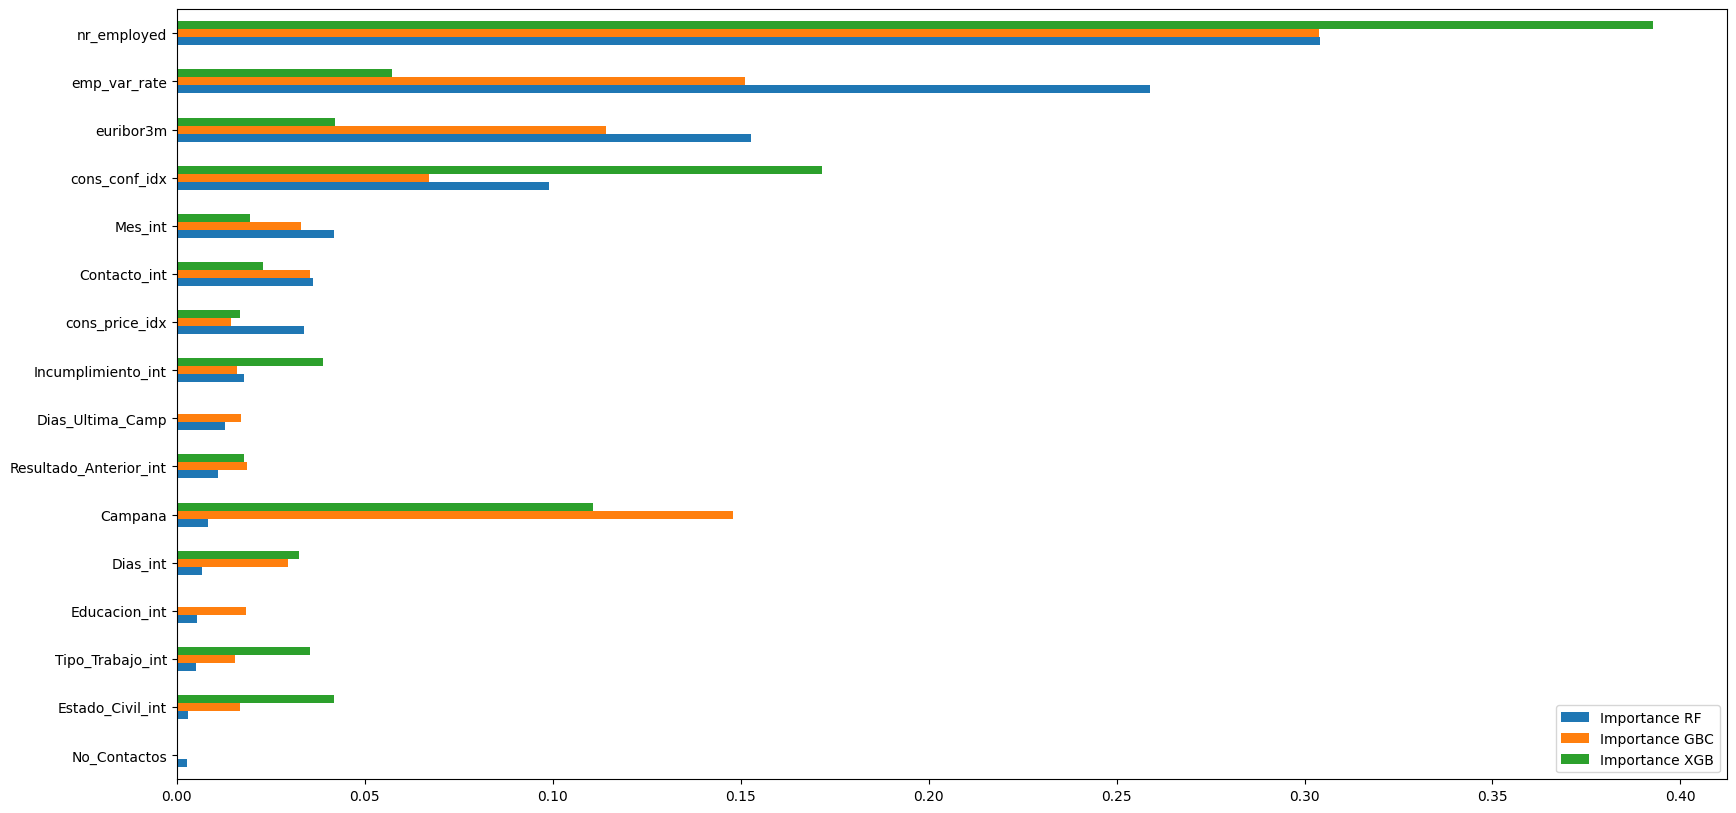

In [ ]:
df_features.plot(kind="barh", figsize=(20, 10))

## 6.2 Prediction Results

In [ ]:
print(f"ROC-AUC Score: {roc_auc_score(target_val, target_pred_rf)}")
print(f"Classification Report:\n  {classification_report(target_val, target_pred_rf)}")
print(f"Confusion Matrix:\n {confusion_matrix(target_val, target_pred_rf)}")

El AUC del ROC es: 0.7305130358437989
Reporte de clasificación:
                precision    recall  f1-score   support

           0       0.95      0.86      0.90      6834
           1       0.33      0.60      0.43       782

    accuracy                           0.83      7616
   macro avg       0.64      0.73      0.66      7616
weighted avg       0.89      0.83      0.85      7616

Matriz de confusion:
 [[5886  948]
 [ 313  469]]


In [39]:
target_pred_rf.shape

(7616,)

In [ ]:
test_pred_rf = model_rf.predict(df_test_train)
submission_rf = pd.DataFrame({"ID": df_test3.index, "y": test_pred_rf})
submission_rf.to_csv("first_submission_2022.csv", index=False)

In [ ]:
df_test2["y"] = test_pred_rf
df_test_30 = df_test2[df_test2["y"] == 0]
df_test_31 = df_test2[df_test2["y"] == 1]

<Axes: title={'center': 'Incumplimiento'}, xlabel='Incumplimiento'>

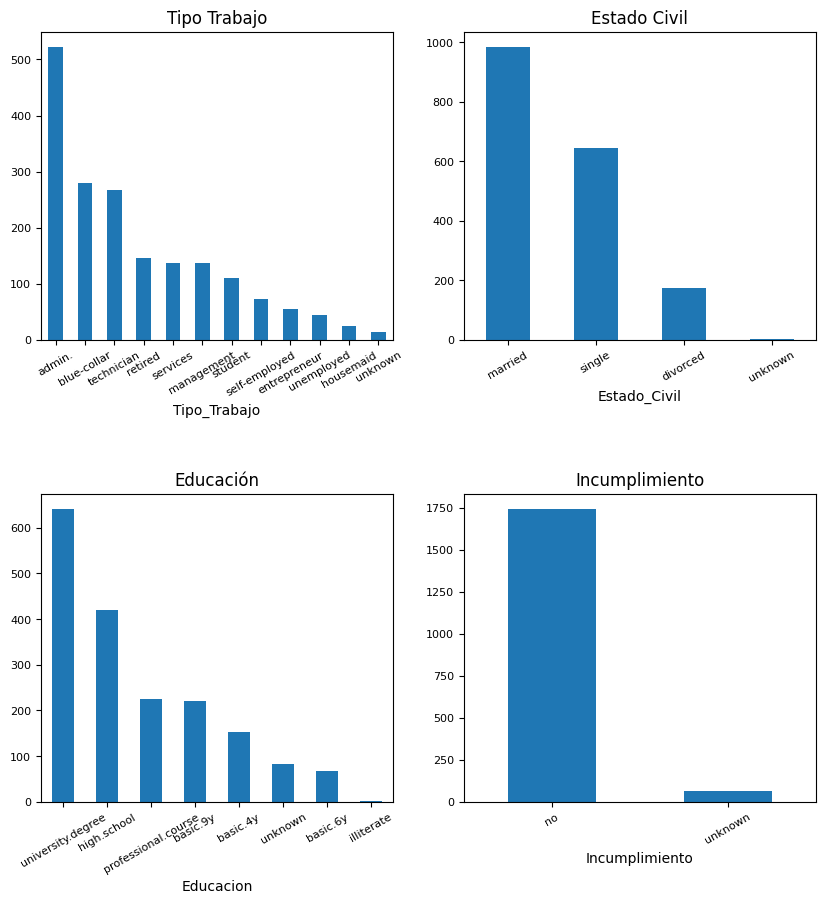

In [ ]:
plt.subplots_adjust(hspace=0.5)
plt.subplot(221)
df_test_31["Tipo_Trabajo"].value_counts().plot(
    kind="bar", title="Tipo Trabajo", rot=30, fontsize=8, figsize=(10, 10)
)
plt.subplot(222)
df_test_31["Estado_Civil"].value_counts().plot(
    kind="bar", title="Estado Civil", rot=30, fontsize=8
)
plt.subplot(223)
df_test_31["Educacion"].value_counts().plot(
    kind="bar", title="Educación", rot=30, fontsize=8
)
plt.subplot(224)
df_test_31["Incumplimiento"].value_counts().plot(
    kind="bar", title="Incumplimiento", rot=30, fontsize=8
)

<Axes: title={'center': 'Resultado Anterior'}, xlabel='Resultado_Anterior'>

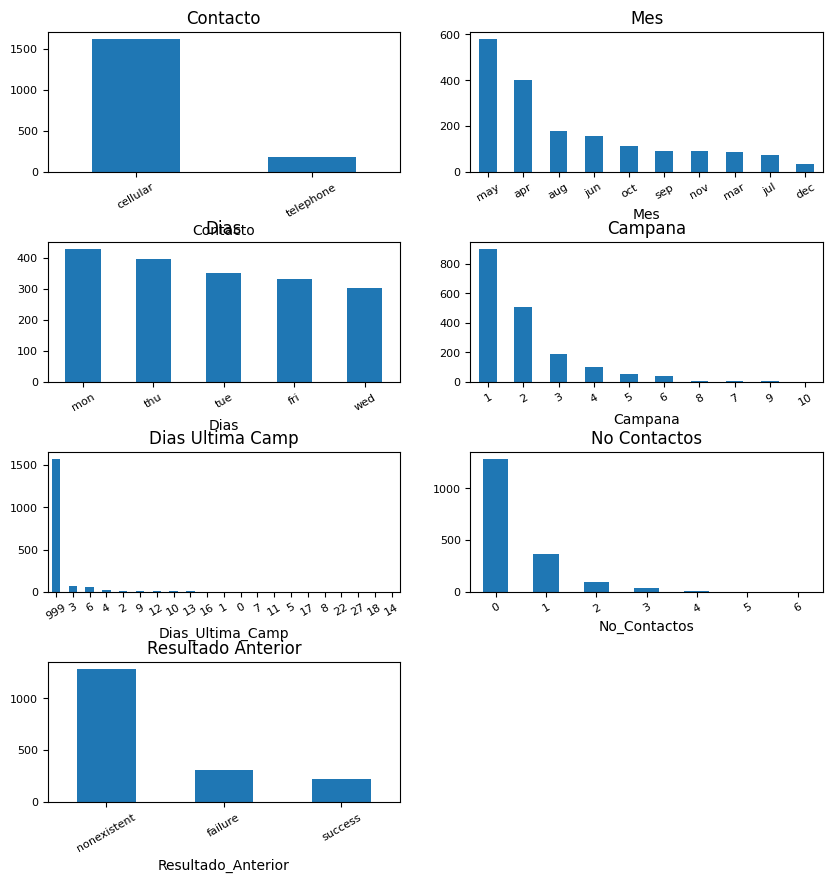

In [ ]:
plt.subplots_adjust(hspace=0.5)
plt.subplot(421)
df_test_31["Contacto"].value_counts().plot(
    kind="bar", title="Contacto", rot=30, fontsize=8, figsize=(10, 10)
)
plt.subplot(422)
df_test_31["Mes"].value_counts().plot(kind="bar", title="Mes", rot=30, fontsize=8)
plt.subplot(423)
df_test_31["Dias"].value_counts().plot(kind="bar", title="Dias", rot=30, fontsize=8)
plt.subplot(424)
df_test_31["Campana"].value_counts().plot(
    kind="bar", title="Campana", rot=30, fontsize=8
)
plt.subplot(425)
df_test_31["Dias_Ultima_Camp"].value_counts().plot(
    kind="bar", title="Dias Ultima Camp", rot=30, fontsize=8
)
plt.subplot(426)
df_test_31["No_Contactos"].value_counts().plot(
    kind="bar", title="No Contactos", rot=30, fontsize=8
)
plt.subplot(427)
df_test_31["Resultado_Anterior"].value_counts().plot(
    kind="bar", title="Resultado Anterior", rot=30, fontsize=8
)

<Axes: ylabel='emp_var_rate'>

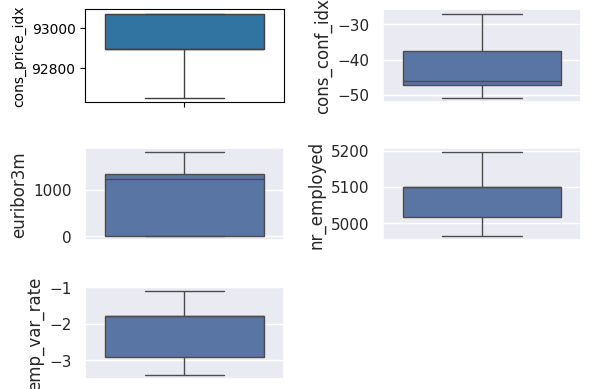

In [ ]:
plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.subplot(321)
sns.set(rc={"figure.figsize": (12, 12)})
sns.boxplot(y=df_test_31["cons_price_idx"], showfliers=False)
plt.subplot(322)
sns.boxplot(y=df_test_31["cons_conf_idx"], showfliers=False)
plt.subplot(323)
sns.boxplot(y=df_test_31["euribor3m"], showfliers=False)
plt.subplot(324)
sns.boxplot(y=df_test_31["nr_employed"], showfliers=False)
plt.subplot(325)
sns.boxplot(y=df_test_31["emp_var_rate"], showfliers=False)